In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

df = pd.read_csv("house_price_dataset_1000.csv")

df.head()

,Location,Area_sqft,Bedrooms,Bathrooms,Parking,Property_Age_Years,Property_Type,Furnishing,Price_Lakh
0,Aurangabad,2999,6,5.0,1.0,16,Apartment,Unfurnished,234.82
1,Nashik,3456,6,NaN,1.0,26,Studio,Unfurnished,294.99
2,Nagpur,1674,4,5.0,2.0,8,Apartment,Semi-Furnished,157.54
3,Aurangabad,1378,3,3.0,NaN,8,Independent House,Semi-Furnished,133.82
4,Thane,2486,5,5.0,1.0,22,Apartment,Semi-Furnished,303.70


In [5]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Rows and Columns: (1000, 9)

Column Names:
Index(['Location', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Parking',
       'Property_Age_Years', 'Property_Type', 'Furnishing', 'Price_Lakh'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Location            1000 non-null   object 
 1   Area_sqft           1000 non-null   int64  
 2   Bedrooms            1000 non-null   int64  
 3   Bathrooms           992 non-null    float64
 4   Parking             992 non-null    float64
 5   Property_Age_Years  1000 non-null   int64  
 6   Property_Type       1000 non-null   object 
 7   Furnishing          992 non-null    object 
 8   Price_Lakh          1000 non-null   float64
dtypes: float64(3), int64(3), object(3)
memory usage: 70.4+ KB


In [6]:
df.isnull().sum()

,0
Location,0
Area_sqft,0
Bedrooms,0
Bathrooms,8
Parking,8
Property_Age_Years,0
Property_Type,0
Furnishing,8
Price_Lakh,0


In [8]:
df["Bathrooms"] = df["Bathrooms"].fillna(df["Bathrooms"].median())
df["Parking"] = df["Parking"].fillna(df["Parking"].median())

df["Furnishing"] = df["Furnishing"].fillna(df["Furnishing"].mode()[0])

print("Missing values handled successfully!")

Missing values handled successfully!


In [10]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Parking,Property_Age_Years,Price_Lakh
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1969.137000,3.832000,3.575000,1.286000,15.239000,221.108680
std,898.316471,1.712515,1.429132,0.773823,8.653598,116.797152
min,452.000000,1.000000,1.000000,0.000000,0.000000,25.000000
25%,1196.500000,2.000000,2.000000,1.000000,8.000000,128.737500
50%,1978.500000,4.000000,4.000000,1.000000,15.000000,210.880000
75%,2694.250000,5.000000,5.000000,2.000000,23.000000,295.660000
max,3495.000000,6.000000,5.000000,3.000000,30.000000,592.520000


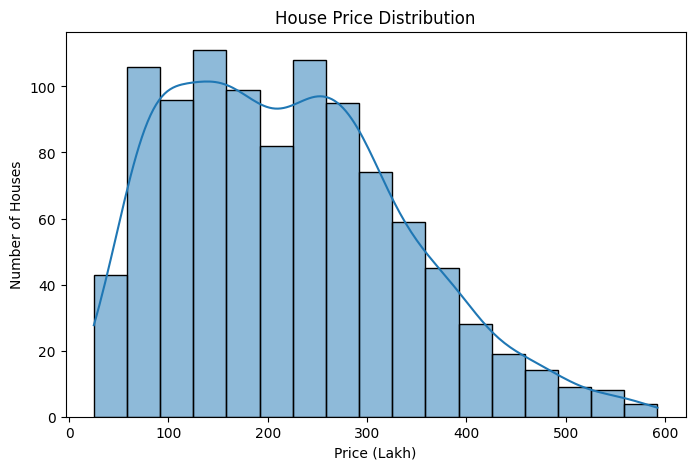

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price_Lakh"], kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price (Lakh)")
plt.ylabel("Number of Houses")

plt.show()

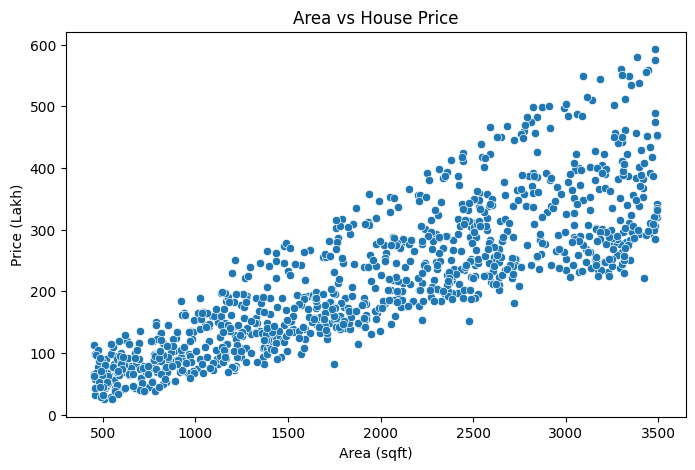

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Area_sqft",
    y="Price_Lakh"
)

plt.title("Area vs House Price")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (Lakh)")

plt.show()

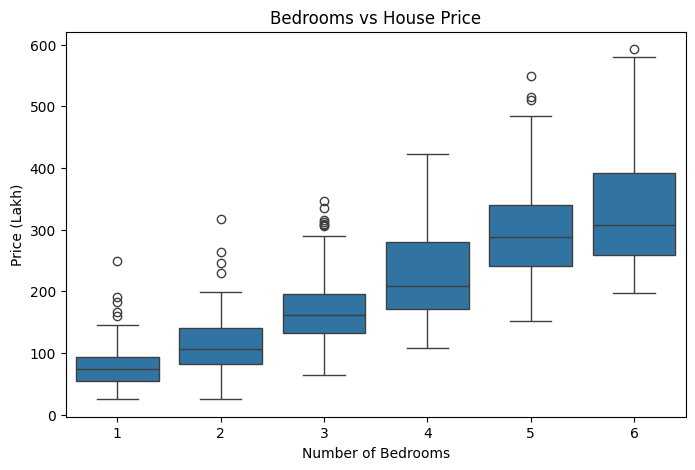

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Bedrooms",
    y="Price_Lakh"
)

plt.title("Bedrooms vs House Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price (Lakh)")

plt.show()

In [14]:
X = df.drop("Price_Lakh", axis=1)
y = df["Price_Lakh"]

print("Features:")
print(X.columns)

print("\nTarget:")
print("Price_Lakh")

Features:
Index(['Location', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Parking',
       'Property_Age_Years', 'Property_Type', 'Furnishing'],
      dtype='object')

Target:
Price_Lakh


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 8)
Testing data: (200, 8)


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:")
print(list(categorical_features))

print("\nNumerical columns:")
print(list(numerical_features))

Categorical columns:
['Location', 'Property_Type', 'Furnishing']

Numerical columns:
['Area_sqft', 'Bedrooms', 'Bathrooms', 'Parking', 'Property_Age_Years']


In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing setup completed!")

Preprocessing setup completed!


In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [22]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Location', 'Property_Type', 'Furnishing'], dtype='object')),
                                                 ('numerical', 'passthrough',
                                                  Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Parking', 'Property_Age_Years'], dtype='object'))])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [23]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print(y_pred[:10])

Predictions completed!
[232.06185 167.1078  238.4258  336.38665 138.0582  390.6986  137.1633
 316.5983  260.56095 440.36825]


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Performance
-----
MAE : 15.766176499999965
RMSE: 19.67443750065484
R² Score: 0.9715945930313262


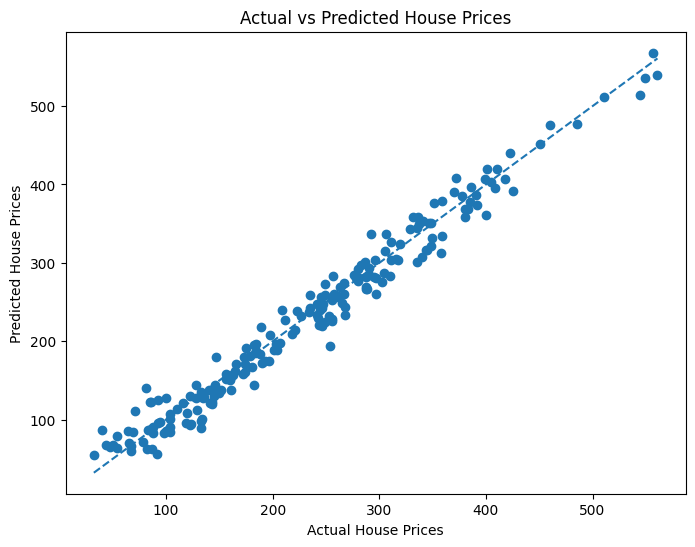

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [26]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

In [27]:
loaded_model = joblib.load("house_price_model.pkl")

new_predictions = loaded_model.predict(X_test)

print("Saved model loaded successfully!")
print("First 5 predictions:")
print(new_predictions[:5])

Saved model loaded successfully!
First 5 predictions:
[232.06185 167.1078  238.4258  336.38665 138.0582 ]


In [28]:
print(X.columns.tolist())

['Location', 'Area_sqft', 'Bedrooms', 'Bathrooms', 'Parking', 'Property_Age_Years', 'Property_Type', 'Furnishing']


In [29]:
print(type(model))
print(model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Location', 'Property_Type', 'Furnishing'], dtype='object')),
                                                 ('numerical', 'passthrough',
                                                  Index(['Area_sqft', 'Bedrooms', 'Bathrooms', 'Parking', 'Property_Age_Years'], dtype='object'))])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, random_state=42))])


In [30]:
import pandas as pd

new_house = pd.DataFrame({
    'Location': ['Mumbai'],
    'Area_sqft': [1000],
    'Bedrooms': [2],
    'Bathrooms': [2],
    'Parking': [1],
    'Property_Age_Years': [5],
    'Property_Type': ['Apartment'],
    'Furnishing': ['Semi-Furnished']
})

predicted_price = loaded_model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 164.44359999999986


In [31]:
import pandas as pd

print("🏠 House Price Prediction")
print("-------------------------")

location = input("Enter Location: ")
area = float(input("Enter Area (sqft): "))
bedrooms = int(input("Enter Number of Bedrooms: "))
bathrooms = int(input("Enter Number of Bathrooms: "))
parking = int(input("Enter Number of Parking: "))
age = int(input("Enter Property Age (years): "))
property_type = input("Enter Property Type: ")
furnishing = input("Enter Furnishing: ")

new_house = pd.DataFrame({
    'Location': [location],
    'Area_sqft': [area],
    'Bedrooms': [bedrooms],
    'Bathrooms': [bathrooms],
    'Parking': [parking],
    'Property_Age_Years': [age],
    'Property_Type': [property_type],
    'Furnishing': [furnishing]
})

prediction = loaded_model.predict(new_house)

print("\n🏠 Predicted House Price:", round(prediction[0], 2))

🏠 House Price Prediction
-------------------------
Enter Location: delhi
Enter Area (sqft): 1000
Enter Number of Bedrooms: 2
Enter Number of Bathrooms: 2
Enter Number of Parking: 1
Enter Property Age (years): 5
Enter Property Type: Apartment
Enter Furnishing: semi furnished

🏠 Predicted House Price: 93.41


In [32]:
from google.colab import files

files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>